# Exploração de Dados do Banco Central do Brasil

Este notebook explora dados econômicos brasileiros usando a biblioteca `python-bcb`.

**Fontes de dados:**
- **SGS (Sistema Gerenciador de Séries Temporais)**: Dados históricos de indicadores
- **Focus**: Expectativas de mercado coletadas pelo BCB

## Setup e Imports

In [2]:
import sys
import os

# Add project root to sys.path to import src modules
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.bcb_client import BCBClient
from src import indicators
import matplotlib.pyplot as plt

# Initialize Client
client = BCBClient()
print("Cliente BCB inicializado com sucesso!")

Cliente BCB inicializado com sucesso!


## 1. Dados SGS (Séries Temporais)

Buscando indicadores econômicos dos últimos 12 meses:
- **IBC-Br**: Índice de Atividade Econômica (mensal)
- **IGP-M**: Índice Geral de Preços do Mercado (mensal)
- **Meta Selic**: Taxa básica de juros (diária)
- **Câmbio**: Dólar e Euro PTAX (diária)
- **CDI**: Certificado de Depósito Interbancário (diária)

In [3]:
# Fetch all SGS indicators (last 12 months)
df_sgs = client.get_sgs_data(indicators.ALL_SGS_CODES, last=12)

print("SGS Data (Last 12 months):")
print(f"Shape: {df_sgs.shape}")
print(f"Period: {df_sgs.index.min()} to {df_sgs.index.max()}")
print(f"\nPrimeiras linhas:")
display(df_sgs.head())
print(f"\nÚltimas linhas:")
display(df_sgs.tail())

SGS Data (Last 12 months):
Shape: (37, 7)
Period: 2024-10-01 00:00:00 to 2025-12-10 00:00:00

Primeiras linhas:


,IBC-Br Bruto,IBC-Br Dessazonalizado,IGP-M Mensal,Meta Selic,Dolar PTAX Venda,Euro PTAX Venda,CDI Diario
Date,,,,,,,
2024-10-01,109.18500,108.04214,NaN,NaN,NaN,NaN,NaN
2024-11-01,105.40008,107.90817,NaN,NaN,NaN,NaN,NaN
2024-12-01,104.09785,106.79723,0.94,NaN,NaN,NaN,NaN
2025-01-01,102.93796,108.37773,0.27,NaN,NaN,NaN,NaN
2025-02-01,106.86305,109.03412,1.06,NaN,NaN,NaN,NaN



Últimas linhas:


,IBC-Br Bruto,IBC-Br Dessazonalizado,IGP-M Mensal,Meta Selic,Dolar PTAX Venda,Euro PTAX Venda,CDI Diario
Date,,,,,,,
2025-12-06,NaN,NaN,NaN,15.0,NaN,NaN,NaN
2025-12-07,NaN,NaN,NaN,15.0,NaN,NaN,NaN
2025-12-08,NaN,NaN,NaN,15.0,NaN,NaN,NaN
2025-12-09,NaN,NaN,NaN,15.0,NaN,NaN,NaN
2025-12-10,NaN,NaN,NaN,15.0,NaN,NaN,NaN


## 2. Separação por Frequência

Os dados têm frequências diferentes (mensal vs diária), então vamos separá-los para análise adequada.

In [4]:
# Separar dados mensais e diários
monthly_cols = ['IBC-Br Bruto', 'IBC-Br Dessazonalizado', 'IGP-M Mensal']
daily_cols = ['Meta Selic', 'Dolar PTAX Venda', 'Euro PTAX Venda', 'CDI Diario']

df_monthly = df_sgs[monthly_cols].dropna(how='all')
df_daily = df_sgs[daily_cols].dropna(how='all')

print("=" * 60)
print("DADOS MENSAIS")
print("=" * 60)
print(f"Shape: {df_monthly.shape}")
print(f"Período: {df_monthly.index.min()} a {df_monthly.index.max()}")
display(df_monthly)

print("\n" + "=" * 60)
print("DADOS DIÁRIOS (últimos 10 registros)")
print("=" * 60)
print(f"Shape: {df_daily.shape}")
print(f"Período: {df_daily.index.min()} a {df_daily.index.max()}")
display(df_daily.tail(10))

DADOS MENSAIS
Shape: (14, 3)
Período: 2024-10-01 00:00:00 a 2025-11-01 00:00:00


,IBC-Br Bruto,IBC-Br Dessazonalizado,IGP-M Mensal
Date,,,
2024-10-01,109.18500,108.04214,NaN
2024-11-01,105.40008,107.90817,NaN
2024-12-01,104.09785,106.79723,0.94
2025-01-01,102.93796,108.37773,0.27
2025-02-01,106.86305,109.03412,1.06
2025-03-01,114.00139,109.81003,-0.34
2025-04-01,112.41307,110.32799,0.24
2025-05-01,108.58398,109.05896,-0.49
2025-06-01,107.20683,108.74411,-1.67



DADOS DIÁRIOS (últimos 10 registros)
Shape: (23, 4)
Período: 2025-11-13 00:00:00 a 2025-12-10 00:00:00


,Meta Selic,Dolar PTAX Venda,Euro PTAX Venda,CDI Diario
Date,,,,
2025-12-01,15.0,5.3463,6.2179,0.055131
2025-12-02,15.0,5.3459,6.2057,NaN
2025-12-03,15.0,NaN,NaN,NaN
2025-12-04,15.0,NaN,NaN,NaN
2025-12-05,15.0,NaN,NaN,NaN
2025-12-06,15.0,NaN,NaN,NaN
2025-12-07,15.0,NaN,NaN,NaN
2025-12-08,15.0,NaN,NaN,NaN
2025-12-09,15.0,NaN,NaN,NaN


## 3. Visualização - Dados Mensais

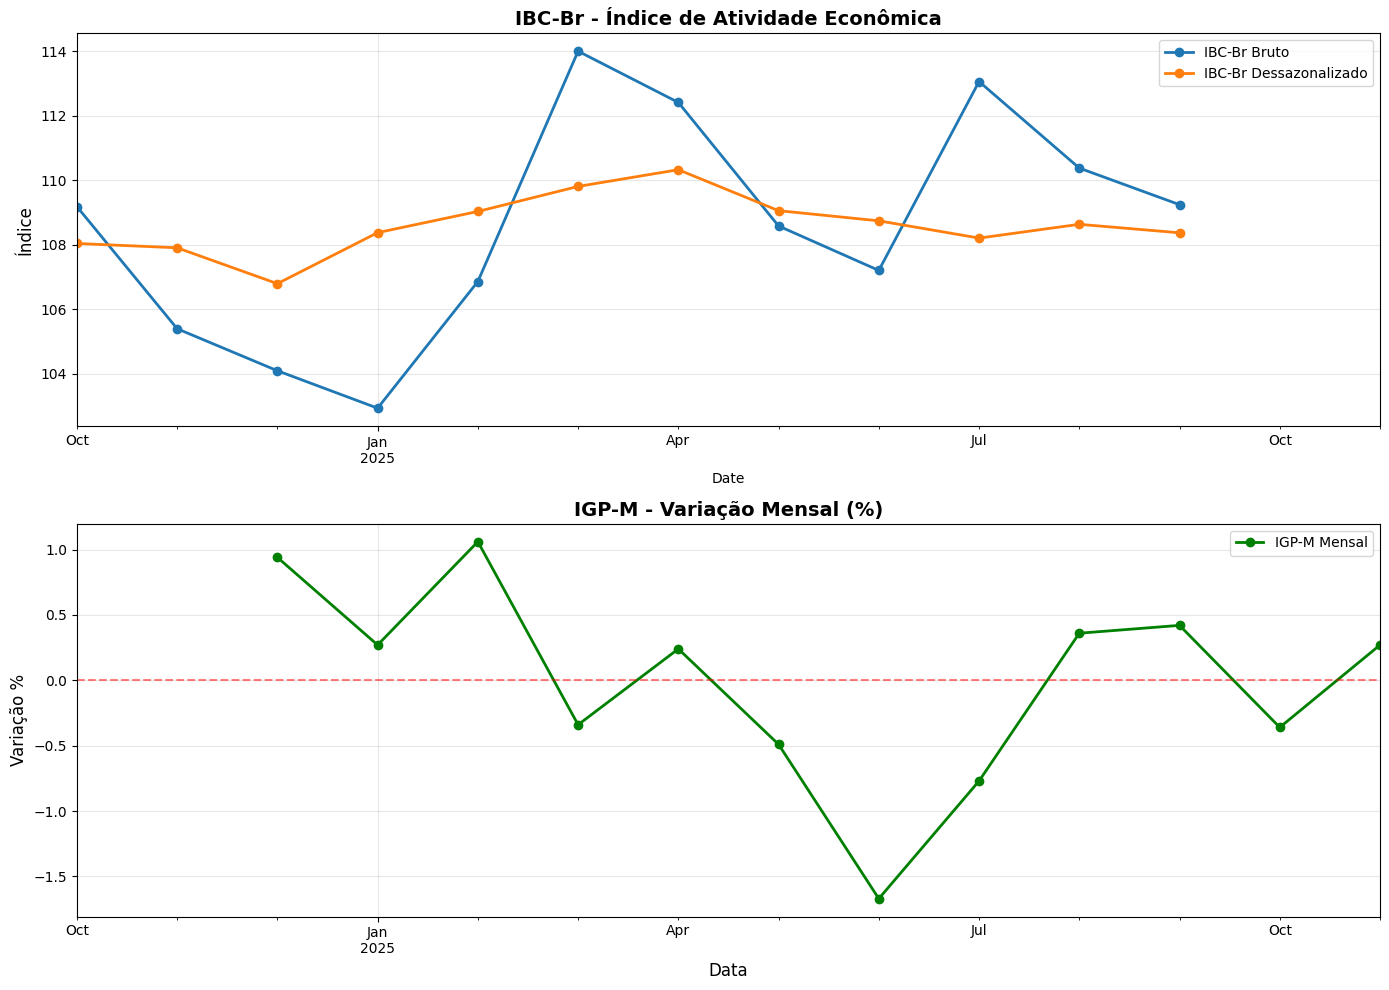

In [5]:
# Plotar dados mensais
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# IBC-Br
df_monthly[['IBC-Br Bruto', 'IBC-Br Dessazonalizado']].plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('IBC-Br - Índice de Atividade Econômica', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Índice', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# IGP-M
df_monthly[['IGP-M Mensal']].plot(ax=axes[1], marker='o', color='green', linewidth=2)
axes[1].set_title('IGP-M - Variação Mensal (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Variação %', fontsize=12)
axes[1].set_xlabel('Data', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero')

plt.tight_layout()
plt.show()

## 4. Visualização - Dados Diários

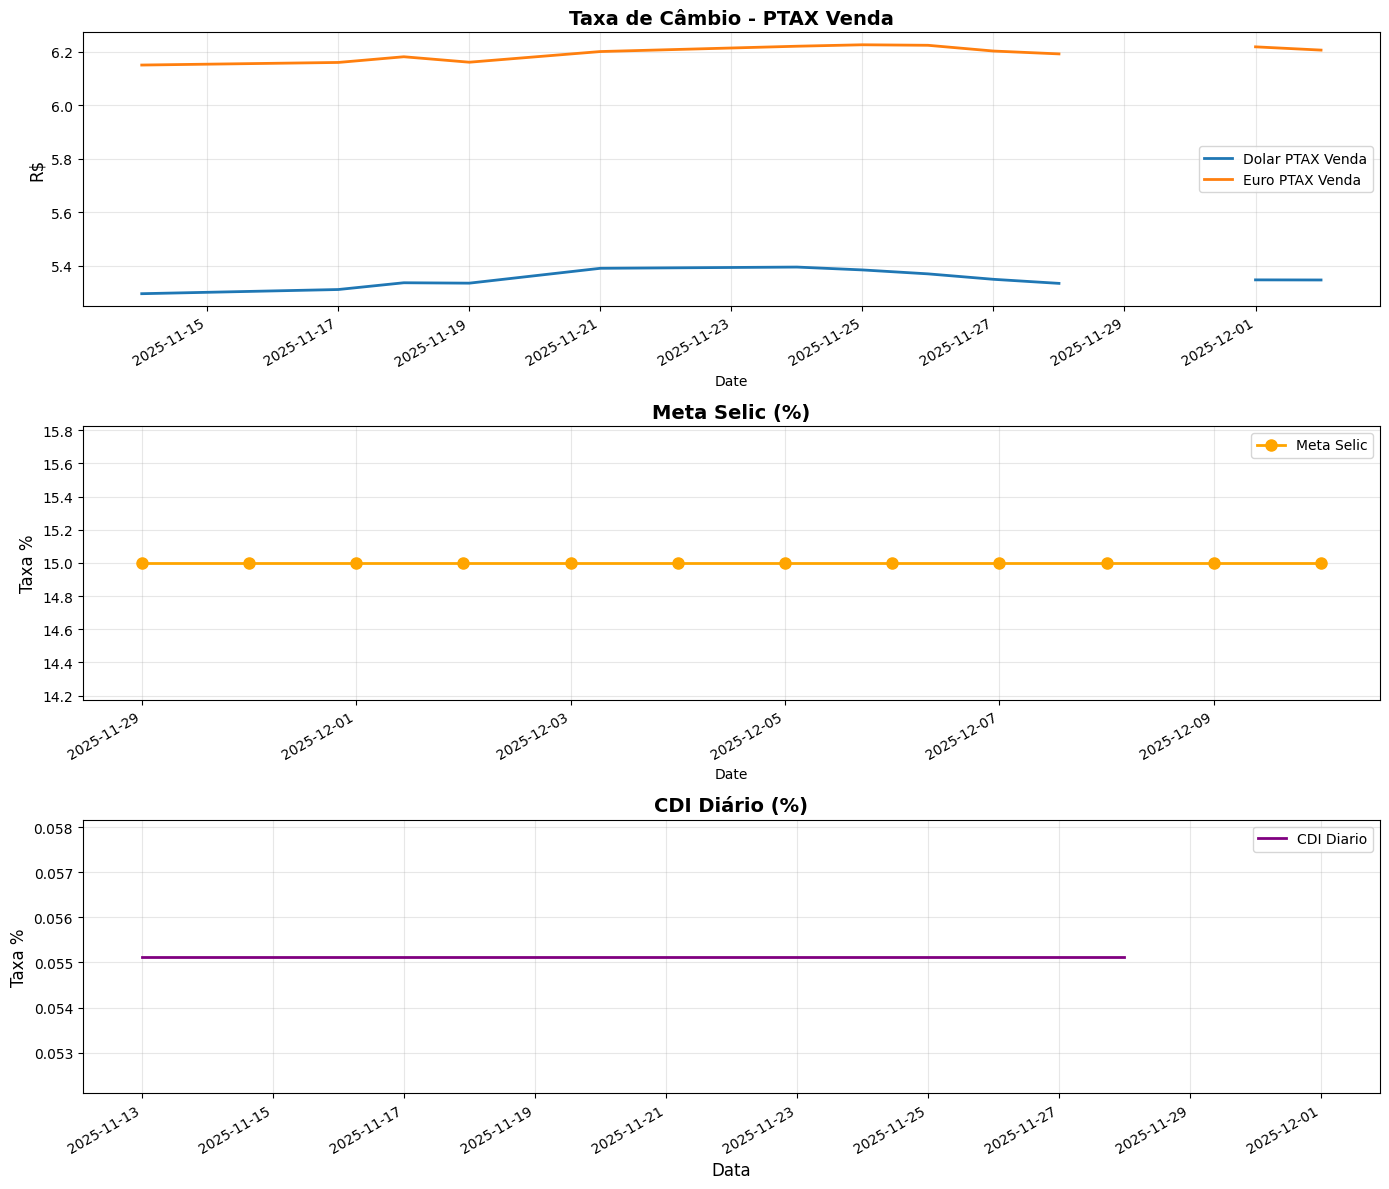

In [6]:
# Plotar dados diários
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Câmbio (Dólar e Euro)
df_daily[['Dolar PTAX Venda', 'Euro PTAX Venda']].plot(ax=axes[0], linewidth=2)
axes[0].set_title('Taxa de Câmbio - PTAX Venda', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R$', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Meta Selic
if not df_daily[['Meta Selic']].dropna().empty:
    df_daily[['Meta Selic']].plot(ax=axes[1], color='orange', marker='o', linewidth=2, markersize=8)
    axes[1].set_title('Meta Selic (%)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Taxa %', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

# CDI
df_daily[['CDI Diario']].plot(ax=axes[2], color='purple', linewidth=2)
axes[2].set_title('CDI Diário (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Taxa %', fontsize=12)
axes[2].set_xlabel('Data', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Estatísticas Descritivas

In [7]:
print("=" * 60)
print("ESTATÍSTICAS - DADOS MENSAIS")
print("=" * 60)
display(df_monthly.describe())

print("\n" + "=" * 60)
print("ESTATÍSTICAS - DADOS DIÁRIOS")
print("=" * 60)
display(df_daily.describe())

ESTATÍSTICAS - DADOS MENSAIS


,IBC-Br Bruto,IBC-Br Dessazonalizado,IGP-M Mensal
count,12.000000,12.000000,12.000000
mean,108.614376,108.609895,-0.005833
std,3.503936,0.912722,0.761774
min,102.937960,106.797230,-1.670000
25%,106.497308,108.167353,-0.392500
50%,108.884490,108.506945,0.255000
75%,110.887338,109.040330,0.375000
max,114.001390,110.327990,1.060000



ESTATÍSTICAS - DADOS DIÁRIOS


,Meta Selic,Dolar PTAX Venda,Euro PTAX Venda,CDI Diario
count,12.0,12.000000,12.000000,1.200000e+01
mean,15.0,5.348683,6.194800,5.513100e-02
std,0.0,0.030765,0.026676,7.247438e-18
min,15.0,5.294600,6.149800,5.513100e-02
25%,15.0,5.333800,6.175700,5.513100e-02
50%,15.0,5.346100,6.201250,5.513100e-02
75%,15.0,5.372475,6.218475,5.513100e-02
max,15.0,5.394200,6.225600,5.513100e-02


## 6. Expectativas Focus - IPCA

Buscando expectativas do mercado para o IPCA das Top 5 instituições.

**Endpoints disponíveis:**
- `ExpectativasMercadoTop5Anuais`: Top 5 instituições (anual)
- `ExpectativasMercadoTop5Mensais`: Top 5 instituições (mensal)
- `ExpectativasMercadoAnuais`: Expectativas anuais
- `ExpectativaMercadoMensais`: Expectativas mensais
- `ExpectativasMercadoInflacao12Meses`: Inflação 12 meses
- `ExpectativasMercadoSelic`: Expectativas Selic

In [8]:
# Fetch Focus Expectations for IPCA (Top 5 Anuais)
df_focus = client.get_focus_expectations(
    endpoint='ExpectativasMercadoTop5Anuais',
    filter_func=lambda ep: ep.Indicador == 'IPCA',
    limit=20,
    orderby_func=lambda ep: ep.Data.desc()
)

print("=" * 60)
print("EXPECTATIVAS FOCUS - IPCA (Top 5 Instituições)")
print("=" * 60)
print(f"Shape: {df_focus.shape}")
print(f"\nColunas disponíveis: {list(df_focus.columns)}")
display(df_focus.head(20))

EXPECTATIVAS FOCUS - IPCA (Top 5 Instituições)
Shape: (20, 9)

Colunas disponíveis: ['Indicador', 'Data', 'DataReferencia', 'tipoCalculo', 'Media', 'Mediana', 'DesvioPadrao', 'Minimo', 'Maximo']


,Indicador,Data,DataReferencia,tipoCalculo,Media,Mediana,DesvioPadrao,Minimo,Maximo
0,IPCA,2025-11-28,2025,C,4.3630,4.3995,0.0807,4.2537,4.4513
1,IPCA,2025-11-28,2026,C,4.0947,4.0007,0.2915,3.7000,4.5827
2,IPCA,2025-11-28,2027,C,3.9000,3.9900,0.1276,3.6800,4.0000
3,IPCA,2025-11-28,2028,C,3.8000,3.8000,0.1951,3.6000,4.0000
4,IPCA,2025-11-28,2029,C,3.7475,3.7450,0.2475,3.5000,4.0000
5,IPCA,2025-11-28,2025,M,4.3691,4.3371,0.0969,4.2630,4.5039
6,IPCA,2025-11-28,2026,M,4.1899,4.0831,0.3796,3.7000,4.6850
7,IPCA,2025-11-28,2027,M,3.4950,3.4900,0.3783,3.0000,4.0000
8,IPCA,2025-11-28,2028,M,3.1525,3.0000,0.2641,3.0000,3.6100
9,IPCA,2025-11-28,2029,M,3.1250,3.0000,0.2165,3.0000,3.5000


## 7. Análise das Expectativas Focus

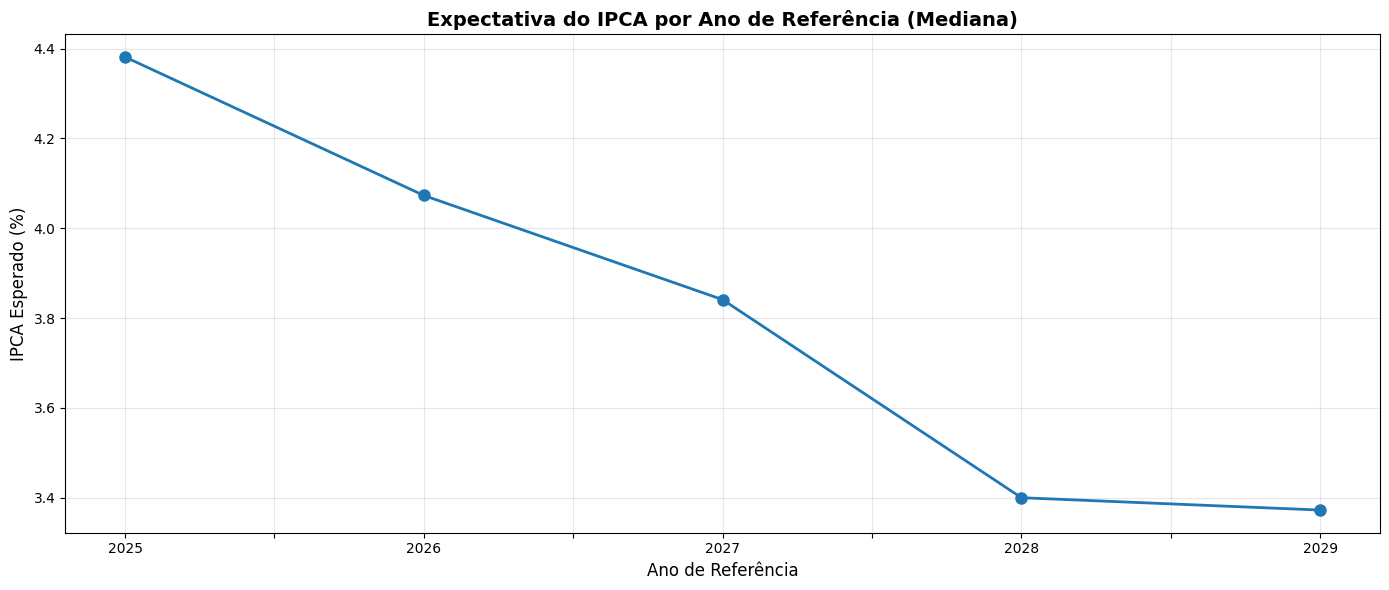


Expectativas por ano:


DataReferencia
2025    4.381150
2026    4.072925
2027    3.840950
2028    3.400000
2029    3.372500
Name: Mediana, dtype: float64

In [9]:
# Análise temporal das expectativas
if not df_focus.empty and 'Mediana' in df_focus.columns:
    # Agrupar por Data de Referência
    if 'DataReferencia' in df_focus.columns:
        df_focus_grouped = df_focus.groupby('DataReferencia')['Mediana'].mean().sort_index()
        
        fig, ax = plt.subplots(figsize=(14, 6))
        df_focus_grouped.plot(ax=ax, marker='o', linewidth=2, markersize=8)
        ax.set_title('Expectativa do IPCA por Ano de Referência (Mediana)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Ano de Referência', fontsize=12)
        ax.set_ylabel('IPCA Esperado (%)', fontsize=12)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\nExpectativas por ano:")
        display(df_focus_grouped)
    else:
        print("Coluna 'DataReferencia' não encontrada")
else:
    print("Dados de expectativas não disponíveis ou coluna 'Mediana' não encontrada")

## 8. Uso Avançado - Acesso Direto ao Endpoint

Para queries mais complexas, você pode acessar o endpoint diretamente:

In [10]:
# Exemplo de uso avançado com acesso direto ao endpoint
ep = client.get_endpoint('ExpectativasMercadoTop5Anuais')

# Query personalizada com filtros múltiplos
df_focus_custom = (
    ep.query()
    .filter(ep.Indicador == 'IPCA')
    .filter(ep.DataReferencia == 2025)
    .limit(10)
    .orderby(ep.Data.desc())
    .collect()
)

print("Expectativas IPCA para 2025:")
display(df_focus_custom)

Expectativas IPCA para 2025:


,Indicador,Data,DataReferencia,tipoCalculo,Media,Mediana,DesvioPadrao,Minimo,Maximo
0,IPCA,2025-11-28,2025,C,4.3630,4.3995,0.0807,4.2537,4.4513
1,IPCA,2025-11-28,2025,M,4.3691,4.3371,0.0969,4.2630,4.5039
2,IPCA,2025-11-28,2025,L,4.4365,4.3885,0.1042,4.3371,4.6287
3,IPCA,2025-11-27,2025,C,4.3901,4.3995,0.0593,4.2800,4.4513
4,IPCA,2025-11-27,2025,M,4.3525,4.2800,0.1076,4.2538,4.5039
5,IPCA,2025-11-27,2025,L,4.4199,4.3885,0.1236,4.2538,4.6287
6,IPCA,2025-11-26,2025,C,4.3901,4.3995,0.0593,4.2800,4.4513
7,IPCA,2025-11-26,2025,M,4.3525,4.2800,0.1076,4.2538,4.5039
8,IPCA,2025-11-26,2025,L,4.4199,4.3885,0.1236,4.2538,4.6287
9,IPCA,2025-11-25,2025,C,4.3734,4.3890,0.0550,4.2800,4.4307


## Resumo

Este notebook demonstrou:
1. ✅ Busca de dados SGS (séries temporais)
2. ✅ Separação de dados por frequência (mensal/diária)
3. ✅ Visualizações de indicadores econômicos
4. ✅ Estatísticas descritivas
5. ✅ Busca de expectativas Focus com filtros OData
6. ✅ Uso avançado da API python-bcb

**Próximos passos:**
- Implementar transformações de dados para unificar frequências
- Criar módulo de validação de dados
- Adicionar mais indicadores econômicos
- Implementar pipeline de atualização automática